In [231]:
import h5py
import os
import matplotlib.pyplot as plt
from glob import glob
from astropy.visualization import ImageNormalize, AsinhStretch, LogStretch
import matplotlib.pylab as pylab
import colorcet as cc
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.io import fits
from astropy import units
import numpy as np
from astropy.wcs import WCS
import glob
import torch
from forward_model import make_forward_model
from astropy.io import fits


# plt.style.use("dark_background")
plt.style.use("science") # Need SciencePLots
params = {
         'axes.labelsize': 20,
         'axes.titlesize': 30,
         'ytick.labelsize' :20,
         'xtick.labelsize' :20,
         'xtick.major.size': 8,
         'xtick.minor.size': 4,
         'xtick.major.width': 2,
         'xtick.minor.width': 2,
         # 'ytick.color': "w",
         # 'xtick.color': "w",
         # 'axes.labelcolor': "w",
         # 'ytick.labelcolor' : "w",
         # 'xtick.labelcolor' : "w",
         }
pylab.rcParams.update(params)

def try_int(x):
    try:
        return int(x)
    except ValueError:
        return x
    
def noise_padding(x, pad, sigma):
    B, C, H, W = x.shape
    PU, PD, PL, PR = pad
    out = torch.zeros(B, C, H+PU+PD, W+PL+PR)
    # Put x in the center of the padded model
    out[..., PD:H+PU, PL:W+PR] = x
    # Create a mask for padding region
    mask = torch.ones_like(out)
    mask[..., PD:H+PU, PL:W+PR] = 0.
    # Noise pad around the model
    z = torch.randn_like(out) * sigma.view(B, 1, 1, 1)
    out += z * mask
    return out

def draw_scale_and_compass(ax, cutout, wcs, rotation=0, scale=1, x0=0.1, y0=0.1, compass_size=0.1, arrow_size=0.001, color="k", lw=2, textpad=5, fontsize=15):
    hdr = wcs.to_header()
    pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(wcs) # in degrees /pixels
    pixel_scale = np.mean([pixel_scale_x, pixel_scale_y]) # for drawing arrows
    M, N = cutout.shape
    
    # nice doc here http://montage.ipac.caltech.edu/docs/headers.html
    # Remember that PC maps pixels to world, so it include a mirror flip of the j coordinate (East-West)
    pc_matrix = wcs.pixel_scale_matrix
    north = np.array([1, 0])
    east = np.array([0, -1]) # accounts for the mirror flip of that coordinate to stay in pixel space
    # Using these prints, the angle of rotation should be printed has the same (+180 undo the mirror flip)
    # print(np.arctan2(pc_matrix[1, 0], pc_matrix[0, 0]) * 180 / np.pi - 90)
    # print(np.arctan2(-pc_matrix[0, 1], pc_matrix[1, 1]) * 180 / np.pi - 90 + 180)
    # Now rotate PC matrix onto our projected coordinate system. This will be useful when images are rotated by 90 degrees or 180 etc. 
    assert rotation % 90 == 0, "Rotation should only be used for images flipped by 90 or 180 degrees"
    theta = rotation * np.pi / 180 / 2 # divide by two to apply this to the PC matrix
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta), np.cos(theta)]])
    pc_matrix = R @ pc_matrix @ R.T
    
    # North arrow 
    ndx = (pc_matrix @ north)[0] * compass_size * N / pixel_scale # apply minus sign to recover the orientation of the image
    ndy = (pc_matrix @ north)[1] * compass_size * N / pixel_scale
    # East arrow
    edx = (pc_matrix @ east)[0] * compass_size * N / pixel_scale
    edy = (pc_matrix @ east)[1] * compass_size * N / pixel_scale
    # some convenient padding solutions
    nrx = -abs(ndx) / np.sqrt(ndx**2 + ndy**2) 
    nry = abs(ndy) / np.sqrt(ndx**2 + ndy**2)
    erx = edx / np.sqrt(edx**2 + edy**2)
    ery = edy / np.sqrt(edx**2 + edy**2)
    # Orientation of the letters N and E
    angle = (np.arctan2(np.abs(ndy), ndx) - np.pi / 2) * 180 / np.pi
    
    # Scale bar
    ax.plot([x0*N, x0*N + scale/pixel_scale_y/3600], [y0*M, y0*M], linewidth=lw, color=color)
    ax.text(x0*N + scale/pixel_scale_x/2/3600, y0*M+textpad/2, f"{abs(scale)}''", fontsize=fontsize, color=color, ha='center', weight='bold')

    # North arrow, on the bottom right corner, pointing up
    ax.arrow(x=(1 - x0)*N, y=y0*M, dx=ndx, dy=ndy, head_width=abs(arrow_size)*N, head_length=abs(arrow_size)*N, fc=color, ec=color, linewidth=lw)
    ax.text((1 - x0)*N+ndx+textpad*nrx, y0*M+ndy+textpad*nry, "N", color=color, fontsize=fontsize, ha='center', rotation=angle, weight='bold')
    
    # East arrow, on the bottom right corner, pointing left
    ax.arrow(x=(1 - x0)*N, y=y0*M, dx=edx, dy=edy, head_width=abs(arrow_size)*N, head_length=abs(arrow_size)*N, fc=color, ec=color, linewidth=lw)
    ax.text((1 - x0)*N+edx+4*textpad*erx/3, y0*M+edy+4*textpad*ery/3, "E", color=color, fontsize=fontsize, ha='center', rotation=angle, weight='bold')
    return ax

In [354]:
coord1 = SkyCoord("9:57:56.5294", "2:27:37.963", unit=(units.hourangle, units.deg))
coord2 = SkyCoord("9:57:46.8867", "2:28:22.735", unit=(units.hourangle, units.deg))
coord3 = SkyCoord("9:57:49.1102", "2:28:19.430", unit=(units.hourangle, units.deg))
coords = [coord1, coord2, coord3]

data = []
data.append(fits.open("../data/connors_target1.fits"))
data.append(fits.open("../data/connors_target2.fits"))
data.append(fits.open("../data/connors_target3.fits"))


In [339]:
sde = "ve_old"

keys = [50, 100, 200, 1000, 3000]
key = 100
targets = [1, 2, 3]
sdes = ["ve_old", "vp", "ve"]
priors = ["probes", "skirt"]
imgs = {i: {sde: {prior: None for prior in priors} for sde in sdes} for i in targets}
reconstructions = {i: {sde: {prior: None for prior in priors} for sde in sdes} for i in targets}
observations = {i: {sde: {prior: None for prior in priors} for sde in sdes} for i in targets}
for target in targets:
    for sde in sdes:
        for prior in priors:
            if sde == "ve_old" and prior == "probes":
                paths = glob.glob(f"../results/posterior_*target{target}*.h5")
                sorted_paths = {key: [p for p in paths if f"guidance{key}_" in p] for key in keys}
                imgs[target][sde][prior] = np.concatenate([h5py.File(f)["model"][:, 0] for f in sorted_paths[key]])
                reconstructions[target][sde][prior] = np.concatenate([h5py.File(f)["reconstruction"][:] for f in sorted_paths[key]])
                observations[target][sde][prior] = np.concatenate([h5py.File(f)["observation"][:] for f in sorted_paths[key]])
            elif sde == "vp":
                try:
                    paths = glob.glob(f"../results/vp_final_posteriors/cosmos_*target{target}*{prior}*.h5")
                    imgs[target][sde] = np.concatenate([h5py.File(f)["model"][:, 0] for f in paths])
                    reconstructions[target][sde][prior] = np.concatenate([h5py.File(f)["reconstruction"][:] for f in paths])
                    observations[target][sde][prior] = np.concatenate([h5py.File(f)["observation"][:] for f in paths[key]])
                except:
                    continue
            elif sde == "ve":
                try:
                    paths = glob.glob(f"../results/ve_final_posteriors/cosmos_*target{target}*{prior}*.h5")
                    imgs[target][sde][prior] = np.concatenate([h5py.File(f)["model"][:, 0] for f in paths])
                    reconstructions[target][sde][prior] = np.concatenate([h5py.File(f)["reconstruction"][:] for f in paths])
                    observations[target][sde][prior] = np.concatenate([h5py.File(f)["observation"][:] for f in paths[key]])
                except:
                    continue

In [325]:
# r = h5py.File(glob.glob(f"../results/ve_final_posteriors/cosmos_*target1*.h5")[2])["reconstruction"]
# o = h5py.File(glob.glob(f"../results/ve_final_posteriors/cosmos_*target1*.h5")[2])["observation"]

# fig, axs = plt.subplots(1, 4, figsize=(16, 4))
# for i in range(4):
#     axs[i].imshow(o[i] - r[0, i])

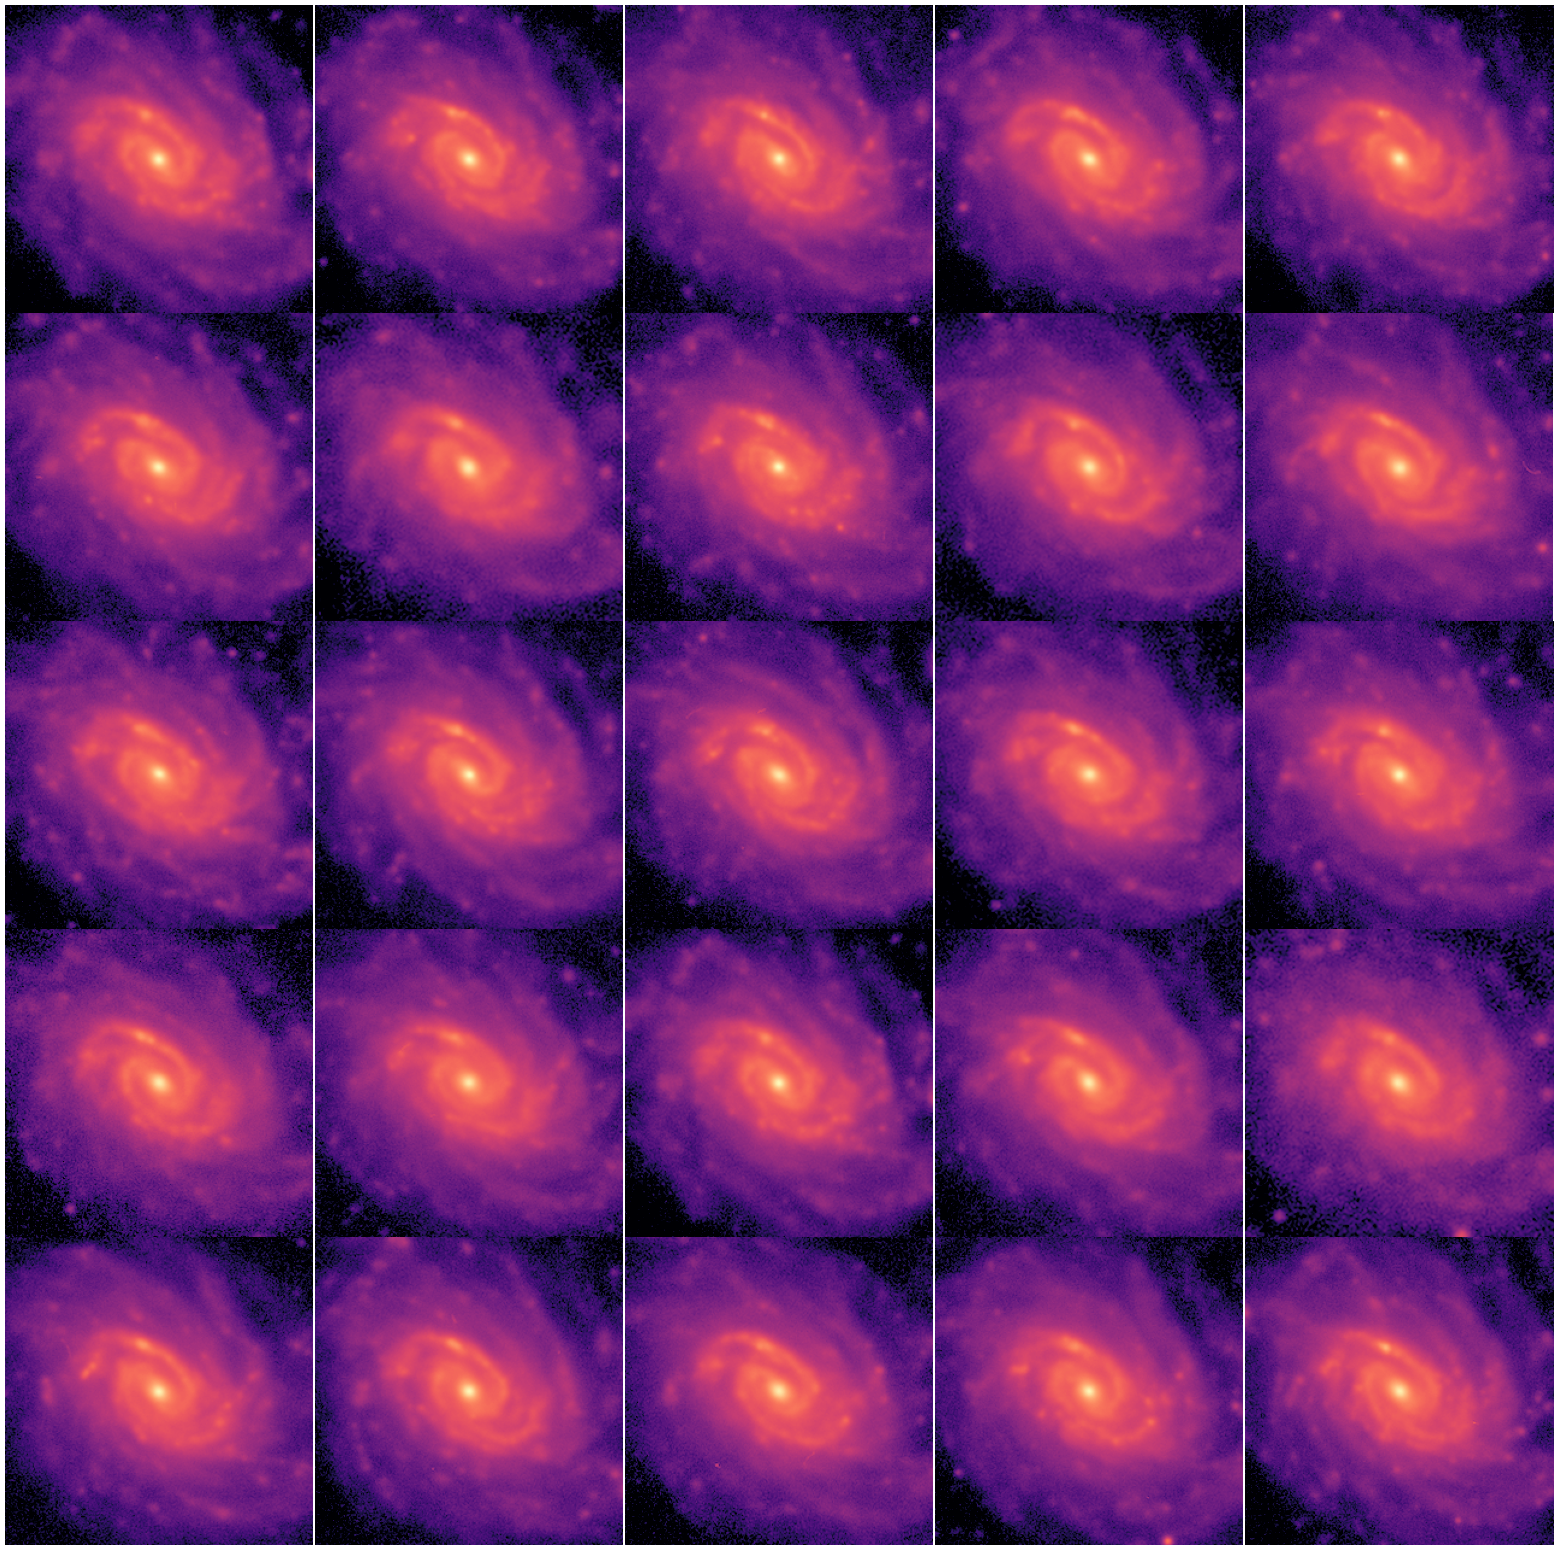

In [330]:
fig, axs = plt.subplots(5, 5, figsize=(20, 20))

target = 2
sde = "ve_old"
prior = "probes"
for i in range(5):
    for j in range(5):
        k = np.random.randint(imgs[target][sde][prior].shape[0])
        axs[i, j].imshow(imgs[target][sde][prior][k], cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-3, vmax=1, clip=True), origin="lower")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# Showcasing residuals

In [341]:
# # Testing the reconstruction

# with fits.open("../data/F814w_WFC3UV_psf.fits") as _data:
#     psf = _data["PRIMARY"].data[None].astype(np.float32) # add the channel dimension, a single channel for now.


# target = 3
# FILTER = "F814W"


# observation = []
# wcs_list = []
# for path in glob.glob(f"../data/connors_target{target}.fits"):
#     _data = fits.open(path)
#     exposures = np.stack([_data[try_int(k)].data for k in [2, 3, 4, 5]], axis=0)
#     wcs_list.extend([WCS(_data[try_int(k)].header, _data) for k in [2, 3, 4, 5]])
#     observation.append(exposures)
# observation = np.concatenate(observation, axis=0)
# observation = torch.tensor(observation).float()[None] # [1, O, pix, pix]

# n_obs = 4

# model_super_sampling_factor = 4
# psf_super_sampling_factor = 4
# model_pixel_size = 0.05 / 4
# model_pixels = 256
# pad = 32
# zero_padding = 8
# forward_model = make_forward_model(
#         psf, 
#         wcs_list, 
#         model_super_sampling_factor=model_super_sampling_factor,
#         psf_super_sampling_factor=psf_super_sampling_factor,
#         model_pixels=model_pixels + 2 * pad,
#         model_pixel_size=model_pixel_size * units.arcsec,
#         fiducial_center=coords[target-1],
#         # fiducial_orientation=args.fiducial_orientation,
#         zero_padding=zero_padding
#         )


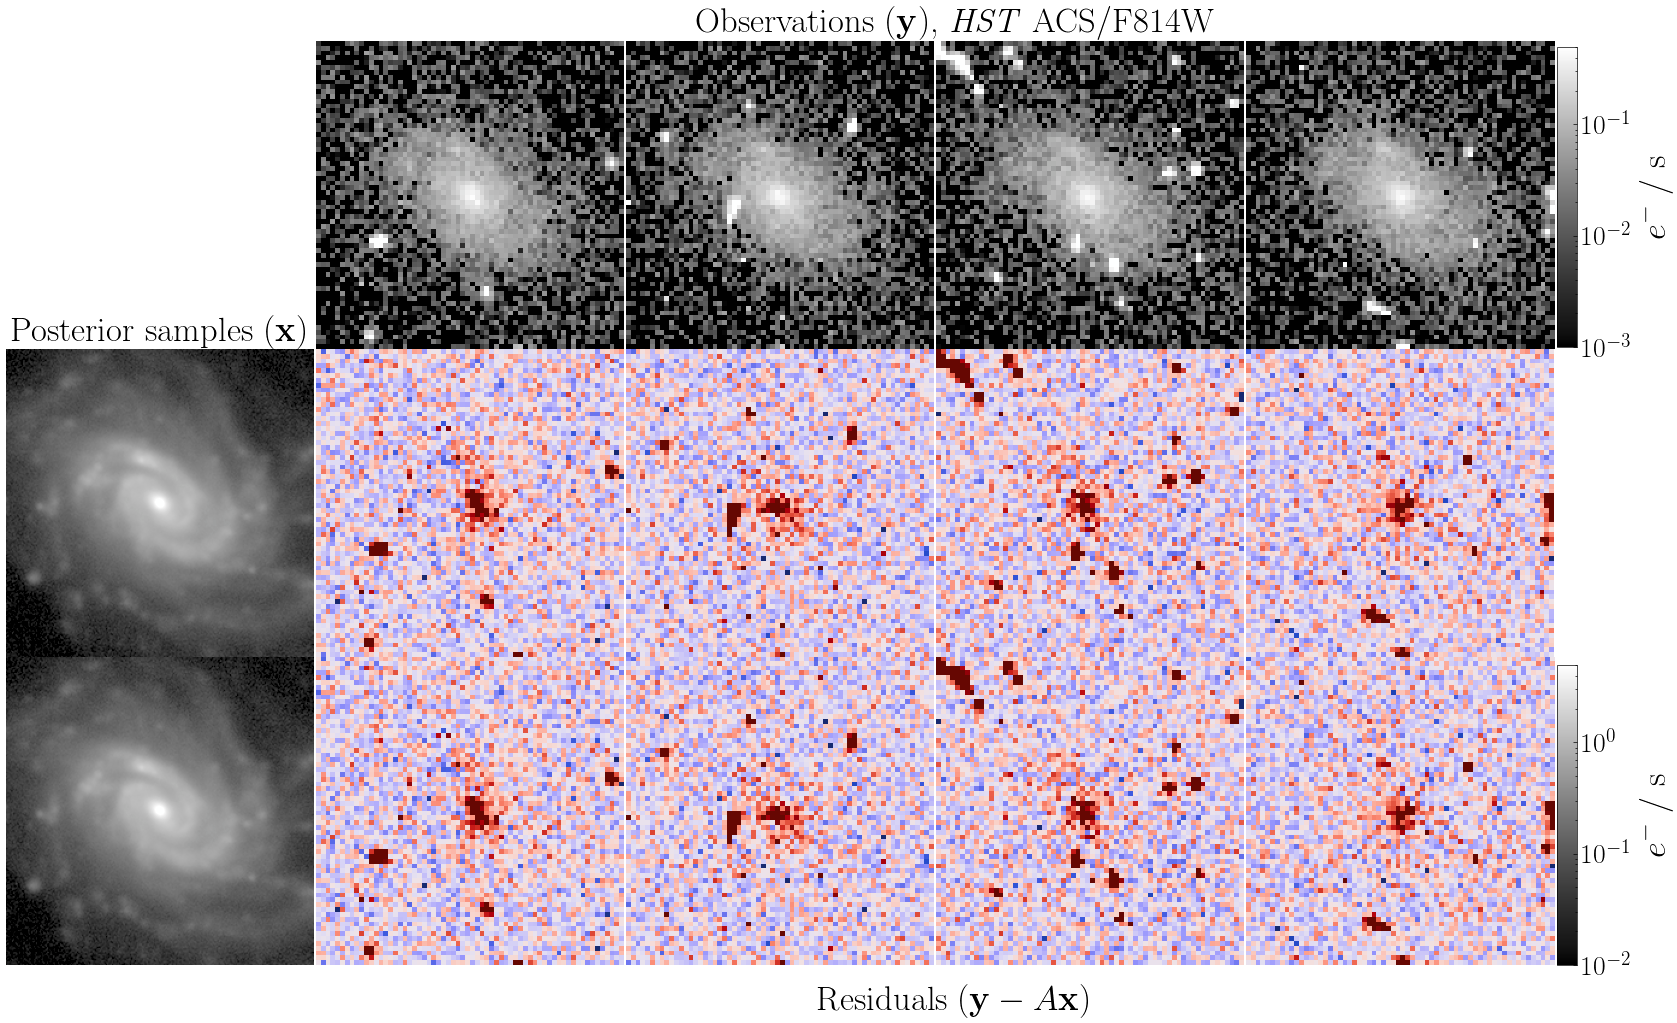

In [352]:
fig, axs = plt.subplots(3, 5, figsize=(20, 12))

target = 2
sde = "ve_old"
prior = "probes"

cmap = cc.cm["gray"]
norm = plt.cm.colors.LogNorm(vmin=1e-3, vmax=0.5, clip=True)

res_cmap = cc.cm["CET_D1A"]
res_norm = ImageNormalize(vmin=-0.08, vmax=0.08)

# Add a title above the four columns on the right, centered
fig.suptitle(r'Observations ($\mathbf{y}$), \textit{HST} ACS/F814W', x=0.6, y=0.91, fontsize=25)  # Adjust x and y to position the title correctly

# Create an axis to hold the title below the columns
fig.text(0.6, 0.08, r'Residuals ($\mathbf{y} - A \mathbf{x}$)', ha='center', va='center', fontsize=25)  # Adjust x and y to position the title correctly


for j in range(4):
    axs[0, j+1].imshow(observations[target][sde][prior][j], cmap=cmap, norm=norm, origin="lower")

k = np.random.randint(imgs[target][sde][prior].shape[0])
im = axs[1, 0].imshow(imgs[target][sde][prior][k], cmap=cmap, norm=norm, origin="lower")
axs[1, 0].set_title(r"Posterior samples ($\mathbf{x}$)", fontsize=25)
# x = torch.tensor(imgs[target][sde][k])[None, None]
# y_hat = forward_model(noise_padding(x, [pad, pad, pad, pad], torch.zeros(1)))
for j in range(4):
    axs[1, j+1].imshow(observations[target][sde][prior][j] - reconstructions[target][sde][prior][k][j], cmap=res_cmap, norm=res_norm, origin="lower")
    # im2 = axs[1, j+1].imshow(data[target-1][2+j].data - y_hat.numpy().squeeze()[j], cmap=res_cmap, norm=res_norm, origin="lower")

# Forward model the solution to make sure everything checks out
im = axs[2, 0].imshow(imgs[target][sde][prior][k], cmap=cmap, norm=norm, origin="lower")
# x = torch.tensor(imgs[target][sde][prior][k])[None, None]
# y_hat = forward_model(noise_padding(x, [pad, pad, pad, pad], torch.zeros(1)))
for j in range(4):
    axs[2, j+1].imshow(observations[target][sde][prior][j] - reconstructions[target][sde][prior][k][j], cmap=res_cmap, norm=res_norm, origin="lower")
    # im2 = axs[2, j+1].imshow(data[target-1][2+j].data - y_hat.numpy().squeeze()[j], cmap=res_cmap, norm=res_norm, origin="lower")

cbar_ax2 = fig.add_axes([0.901, 0.625, 0.01, 0.25])
fig.colorbar(im, cax=cbar_ax2)
cbar_ax2.set_ylabel(r"$e^{-}$ / s", fontsize=25, color="k")

cbar_ax2 = fig.add_axes([0.901, 0.11, 0.01, 0.25])
fig.colorbar(im2, cax=cbar_ax2)
cbar_ax2.set_ylabel(r"$e^{-}$ / s", fontsize=25, color="k")

for i in range(3):
    for j in range(5):
        axs[i, j].axis("off")

plt.subplots_adjust(hspace=0, wspace=0)

plt.savefig(f"../results/showcasing_residuals_{sde}_oldslic_cosmos_target{target}_{prior}.pdf")

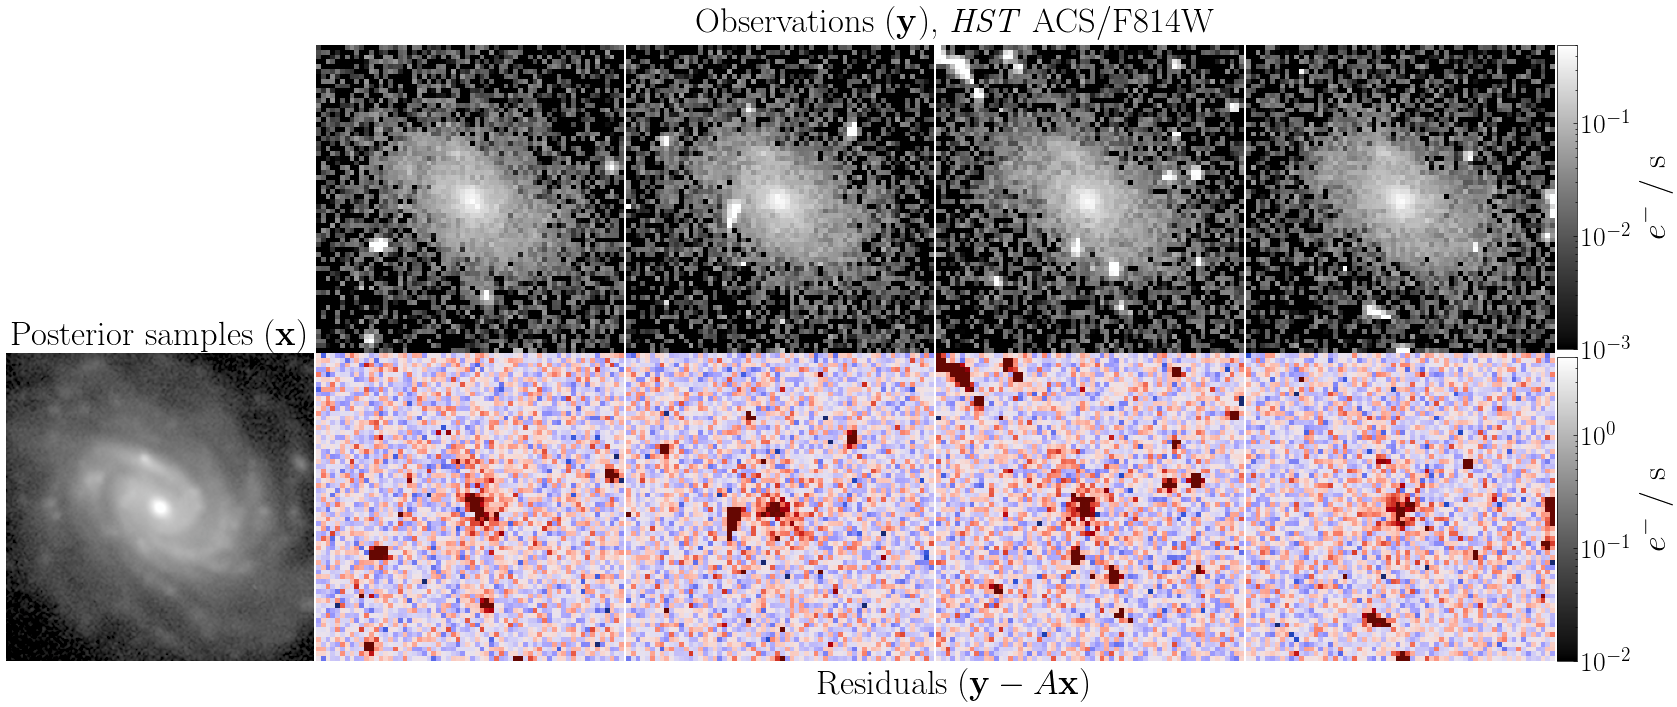

In [353]:
fig, axs = plt.subplots(2, 5, figsize=(20, 8))

cmap = cc.cm["gray"]
norm = plt.cm.colors.LogNorm(vmin=1e-3, vmax=0.5, clip=True)

res_cmap = cc.cm["CET_D1A"]
res_norm = ImageNormalize(vmin=-0.08, vmax=0.08)

# Add a title above the four columns on the right, centered
fig.suptitle(r'Observations ($\mathbf{y}$), \textit{HST} ACS/F814W', x=0.6, y=0.93, fontsize=25)  # Adjust x and y to position the title correctly

# Create an axis to hold the title below the columns
fig.text(0.6, 0.08, r'Residuals ($\mathbf{y} - A \mathbf{x}$)', ha='center', va='center', fontsize=25)  # Adjust x and y to position the title correctly


for j in range(4):
    axs[0, j+1].imshow(observations[target][sde][prior][j], cmap=cmap, norm=norm, origin="lower")

k = np.random.randint(imgs[target][sde][prior].shape[0])
im = axs[1, 0].imshow(imgs[target][sde][prior][k], cmap=cmap, norm=norm, origin="lower")
axs[1, 0].set_title(r"Posterior sample ($\mathbf{x}$)", fontsize=25)

im = axs[1, 0].imshow(imgs[target][sde][prior][k], cmap=cmap, norm=norm, origin="lower")
axs[1, 0].set_title(r"Posterior samples ($\mathbf{x}$)", fontsize=25)
# x = torch.tensor(imgs[target][sde][k])[None, None]
# y_hat = forward_model(noise_padding(x, [pad, pad, pad, pad], torch.zeros(1)))
for j in range(4):
    axs[1, j+1].imshow(observations[target][sde][prior][j] - reconstructions[target][sde][prior][k][j], cmap=res_cmap, norm=res_norm, origin="lower")
    # im2 = axs[1, j+1].imshow(data[target-1][2+j].data - y_hat.numpy().squeeze()[j], cmap=res_cmap, norm=res_norm, origin="lower")
    

cbar_ax2 = fig.add_axes([0.901, 0.5, 0.01, 0.38])
fig.colorbar(im, cax=cbar_ax2)
cbar_ax2.set_ylabel(r"$e^{-}$ / s", fontsize=25, color="k")

cbar_ax2 = fig.add_axes([0.901, 0.11, 0.01, 0.38])
fig.colorbar(im2, cax=cbar_ax2)
cbar_ax2.set_ylabel(r"$e^{-}$ / s", fontsize=25, color="k")

for i in range(2):
    for j in range(5):
        axs[i, j].axis("off")

plt.subplots_adjust(hspace=0, wspace=0)

plt.savefig(f"../results/showcasing_residuals_{sde}_oldslic_cosmos_target{target}_2columns.pdf")

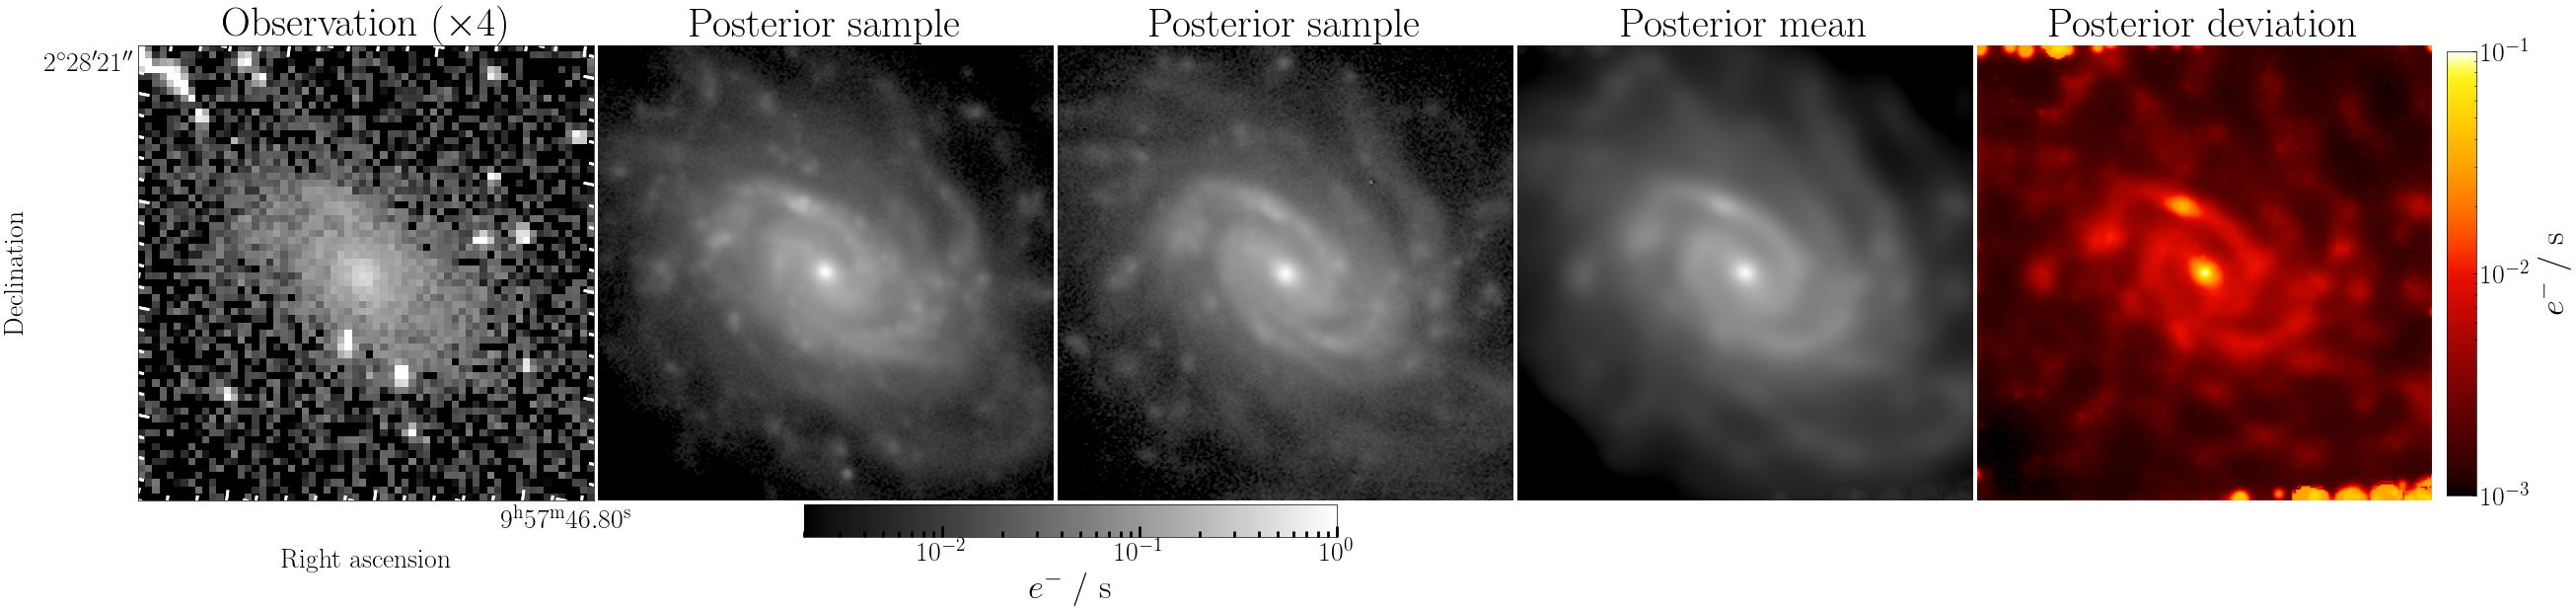

In [356]:
target = 2

fig = plt.figure(figsize=(30, 6))
cmap = cc.cm["gray"]
cmap_std = cc.cm["fire"]
# cmap = "magma"
# cmap_std = "hot"

norm = plt.cm.colors.LogNorm(vmin=2e-3, vmax=1, clip=True) # change so it makes sense with your units
norm_std = plt.cm.colors.LogNorm(vmin=1e-3, vmax=1e-1, clip=True) # also change this as well

# norm = ImageNormalize(1e3*dirty_image[..., None, None].cpu().numpy(), vmin = 0, stretch = AsinhStretch())

img = data[target-1][4].data
wcs = WCS(data[target-1][4].header, data[target-1])
ax = fig.add_subplot(151, projection=wcs)
im1 = ax.imshow(img, cmap=cmap, norm=norm)
ax.tick_params(axis='both', which='both', color='white')
ax.set_ylabel("Declination")
ax.set_xlabel("Right ascension")
ax.set_title(r"Observation ($\times 4$)")

for i in range(2):
    k = np.random.randint(imgs[target][sde][prior].shape[0])
    img = imgs[target][sde][prior][k]
    ax = fig.add_subplot(int(f"15{i+2}"))
    ax.imshow(img, cmap=cmap, norm=norm, origin="lower")
    ax.axis("off")
    ax.tick_params(axis='both', which='both', color='white')
    ax.set_title("Posterior sample")

# Mean image (or mode img)
ax = fig.add_subplot(int(f"154"))
# draw_scale_and_compass(ax, img, wcs, scale=1, x0=0.1, y0=0.1, compass_size=0.1, arrow_size=0.03, color="w", lw=2, textpad=10, fontsize=30)
ax.imshow(imgs[target][sde][prior].mean(axis=0), cmap=cmap, norm=norm, origin="lower")
# ax.imshow(np.median(imgs[target], axis=0), cmap=cmap, norm=norm, origin="lower")

ax.axis("off")
ax.tick_params(axis='both', which='both', color='white')
ax.set_title("Posterior mean") # or mode

# Standard deviation
ax = fig.add_subplot(int(f"155"), projection=wcs)
im2 = ax.imshow(imgs[target][sde][prior].std(axis=0), cmap=cmap_std, norm=norm_std)
ax.axis("off")
ax.tick_params(axis='both', which='both', color='white')
ax.set_title("Posterior deviation") # or mode

cbar_ax = fig.add_axes([0.35, 0.05, 0.18, 0.055])  # Position colorbar at [left, bottom, width, height]
cb1 = plt.colorbar(im1, cax=cbar_ax, orientation="horizontal")
cbar_ax.set_xlabel(r"$e^{-}$ / s", fontsize=25)

cbar_ax2 = fig.add_axes([0.905, 0.12, 0.01, 0.75])
fig.colorbar(im2, cax=cbar_ax2)
cbar_ax2.set_ylabel(r"$e^{-}$ / s", fontsize=25)

plt.subplots_adjust(hspace=0, wspace=0.01)

# plt.savefig(f"../results/summary_connor_target{TARGET}_probes_vp.png", bbox_inches="tight")

# SMACS

In [368]:
coord0 = SkyCoord("7:23:24.5462", "-73:27:20.172", unit=(units.hourangle, units.deg))
coord1 = SkyCoord("7:23:22.0805", "-73:27:24.575", unit=(units.hourangle, units.deg))
coord2 = SkyCoord("7:23:20.7483", "-73:26:07.203", unit=(units.hourangle, units.deg))

coords = [coord0, coord1, coord2]

import sys
sys.path.append("../scripts")
from forward_model import make_wcs

In [369]:

targets = [0, 1, 2]
sdes = ["vp"]
priors = ["probes", "skirt"]
imgs = {i: {sde: {prior: None for prior in priors} for sde in sdes} for i in targets}
reconstructions = {i: {sde: {prior: None for prior in priors} for sde in sdes} for i in targets}
observations = {i: {sde: {prior: None for prior in priors} for sde in sdes} for i in targets}
for target in targets:
    for sde in sdes:
        for prior in priors:
            if sde == "vp":
                try:
                    paths = glob.glob(f"../results/vp_final_posteriors/smacs_*target{target}*{prior}*.h5")
                    imgs[target][sde][prior] = np.concatenate([h5py.File(f)["model"][:, 0] for f in paths])
                    reconstructions[target][sde][prior] = np.concatenate([h5py.File(f)["reconstruction"][:] for f in paths])
                    observations[target][sde][prior] = np.concatenate([h5py.File(f)["observation"][:] for f in paths])
                except:
                    continue

In [370]:
FILTER = "F105WO1"
data = {t: [] for t in [0, 1, 2]}
for target in [0, 1, 2]:
    paths = glob.glob(f"../data/smacs*target{target}*{FILTER.upper()}*.fits")
    for p in paths:
        data[target].append(fits.open(p))

In [371]:
jwst_imgs = {target: None for target in [0, 1, 2]}
wcs_jwst = {target: None for target in [0, 1, 2]}
for target in [0, 1, 2]:
    jwst_cutout = fits.open(f"../data/smacs_jwst_i2d_target{target}_F115W.fits")
    wcs_jwst[target] = WCS(jwst_cutout[1].header)
    jwst_imgs[target] = jwst_cutout[1].data

Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [299]:
# # Testing the reconstruction

# target = 2
# FILTER = "F105WO1"
# OBS = 0 # from 0 to 3, which target to plot


# with fits.open("../data/F814w_WFC3UV_psf.fits") as _data:
#     psf = _data["PRIMARY"].data[None].astype(np.float32) # add the channel dimension, a single channel for now.


# observation = []
# wcs_list = []
# for path in glob.glob(f"../data/smacs*target{target}*{FILTER.upper()}*.fits"):
#     _data = fits.open(path)
#     exposures = np.stack([_data[try_int(k)].data for k in ["SCI"]], axis=0)
#     wcs_list.extend([WCS(_data[try_int(k)].header, _data) for k in ["SCI"]])
#     observation.append(exposures)
# observation = np.concatenate(observation, axis=0)
# observation = torch.tensor(observation).float()[None] # [1, O, pix, pix]

# n_obs = 4

# model_super_sampling_factor = 4
# psf_super_sampling_factor = 8
# model_pixel_size = 0.13 / 8
# model_pixels = 256
# pad = 32
# zero_padding = 8
# forward_model = make_forward_model(
#         psf, 
#         wcs_list, 
#         model_super_sampling_factor=model_super_sampling_factor,
#         psf_super_sampling_factor=psf_super_sampling_factor,
#         model_pixels=model_pixels + 2 * pad,
#         model_pixel_size=model_pixel_size * units.arcsec,
#         fiducial_center=coords[target],
#         # fiducial_orientation=args.fiducial_orientation,
#         zero_padding=zero_padding
#         )


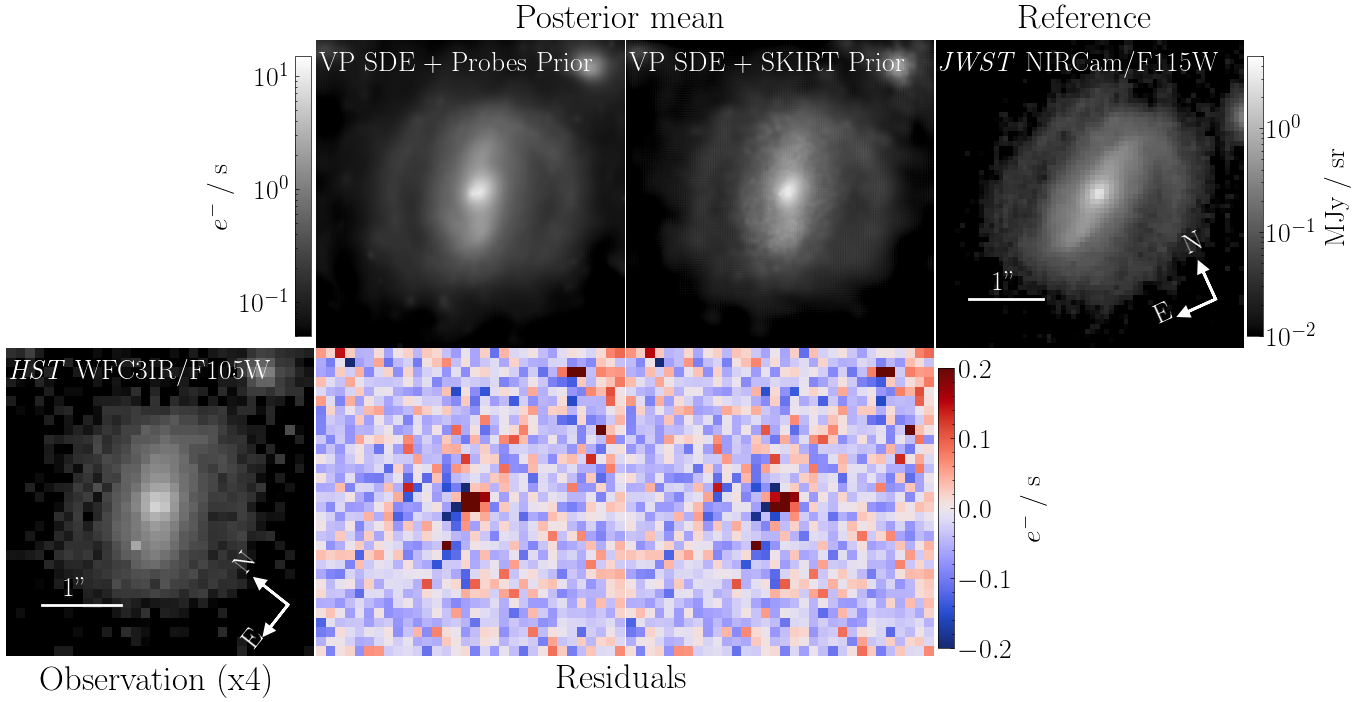

In [307]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))

target = 2

cmap = cc.cm["gray"]
norm = plt.cm.colors.LogNorm(vmin=5e-2, vmax=15, clip=True)
norm_jwst = plt.cm.colors.LogNorm(vmin=1e-2, vmax=5, clip=True)

res_cmap = cc.cm["CET_D1A"]
res_norm = ImageNormalize(vmin=-0.2, vmax=0.2)

data_wcs = WCS(data[target][OBS]["SCI"].header, data[target][OBS])
# img = np.rot90(data[target][OBS]["SCI"].data, k=1)
img = np.rot90(observations[target][sde][prior][OBS], k=1)
im1 = axs[1, 0].imshow(img, cmap=cmap, norm=norm, origin="lower")
axs[1, 0].annotate(r"\textit{HST} WFC3IR/F105W", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
draw_scale_and_compass(axs[1, 0], img, data_wcs,  scale=1, x0=0.1, y0=0.15, compass_size=0.1, arrow_size=0.03, color="w", lw=2, textpad=2, fontsize=20)


k = np.random.randint(imgs[target]["vp"]["probes"].shape[0])
# x = torch.tensor(imgs[target][sde][prior][k])[None, None]
# y_hat = forward_model(noise_padding(x, [pad, pad, pad, pad], torch.zeros(1)))
# axs[0, 1].imshow(np.rot90(imgs[target]["vp"]["probes"][k]), cmap=cmap, norm=norm, origin="lower")
axs[0, 1].imshow(np.rot90(imgs[target]["vp"]["probes"].mean(axis=0)), cmap=cmap, norm=norm, origin="lower")
axs[0, 1].annotate("VP SDE + Probes Prior", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
# Compare recosntruction of on of the target, the first one in this case
axs[1, 1].imshow(np.rot90(observations[target][sde][prior][OBS] - reconstructions[target][sde][prior][k][OBS]), cmap=res_cmap, norm=res_norm, origin="lower")
# axs[1, 1].imshow(np.rot90(data[target][OBS]["SCI"].data - y_hat.numpy().squeeze()[OBS]), cmap=res_cmap, norm=res_norm, origin="lower")


k = np.random.randint(imgs[target]["vp"]["skirt"].shape[0])
# x = torch.tensor(imgs[target][sde][prior][k])[None, None]
# y_hat = forward_model(noise_padding(x, [pad, pad, pad, pad], torch.zeros(1)))
# axs[0, 1].imshow(np.rot90(imgs[target]["vp"]["probes"][k]), cmap=cmap, norm=norm, origin="lower")
axs[0, 2].annotate("VP SDE + SKIRT Prior", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
axs[0, 2].imshow(np.rot90(imgs[target]["vp"]["skirt"].mean(axis=0)), cmap=cmap, norm=norm, origin="lower")
# Compare recosntruction of on of the target, the first one in this case
axs[1, 2].imshow(np.rot90(observations[target][sde][prior][OBS] - reconstructions[target][sde][prior][k][OBS]), cmap=res_cmap, norm=res_norm, origin="lower")
# axs[1, 2].imshow(np.rot90(data[target][OBS]["SCI"].data - y_hat.numpy().squeeze()[OBS]), cmap=res_cmap, norm=res_norm, origin="lower")


im2 = axs[0, -1].imshow(jwst_imgs[target], cmap=cmap, norm=norm_jwst, origin="lower") 
axs[0, -1].annotate(r"\textit{JWST} NIRCam/F115W", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
draw_scale_and_compass(axs[0, -1], jwst_imgs[target], wcs_jwst[target], rotation=90,  scale=1, x0=0.1, y0=0.15, compass_size=0.1, arrow_size=0.03, color="w", lw=2, textpad=4, fontsize=20)


fig.text(0.51, 0.905, r'Posterior mean', ha='center', va='center', fontsize=25)  # Adjust x and y to position the title correctly
fig.text(0.8, 0.905, r'Reference', ha='center', va='center', fontsize=25)  # Adjust x and y to position the title correctly
fig.text(0.51, 0.08, r'Residuals', ha='center', va='center', fontsize=25)
fig.text(0.22, 0.08, r'Observation (x4)', ha='center', va='center', fontsize=25)

cbar_ax = fig.add_axes([0.306, 0.51, 0.01, 0.35])
fig.colorbar(im1, cax=cbar_ax)
cbar_ax.set_ylabel(r"$e^{-}$ / s", fontsize=20, color="k")
cbar_ax.yaxis.set_ticks_position('left')
cbar_ax.yaxis.set_label_position("left")

cbar_ax2 = fig.add_axes([0.901, 0.51, 0.01, 0.35])
fig.colorbar(im2, cax=cbar_ax2)
cbar_ax2.set_ylabel(r"MJy / sr", fontsize=20, color="k")

cbar_ax3 = fig.add_axes([0.708, 0.12, 0.01, 0.35])
fig.colorbar(im3, cax=cbar_ax3)
cbar_ax3.set_ylabel(r"$e^{-}$ / s", fontsize=20, color="k")

for i in range(2):
    for j in range(4):
        axs[i, j].axis("off")

plt.subplots_adjust(hspace=0, wspace=0)

plt.savefig(f"../results/comparison_smacs_target{target}.pdf")

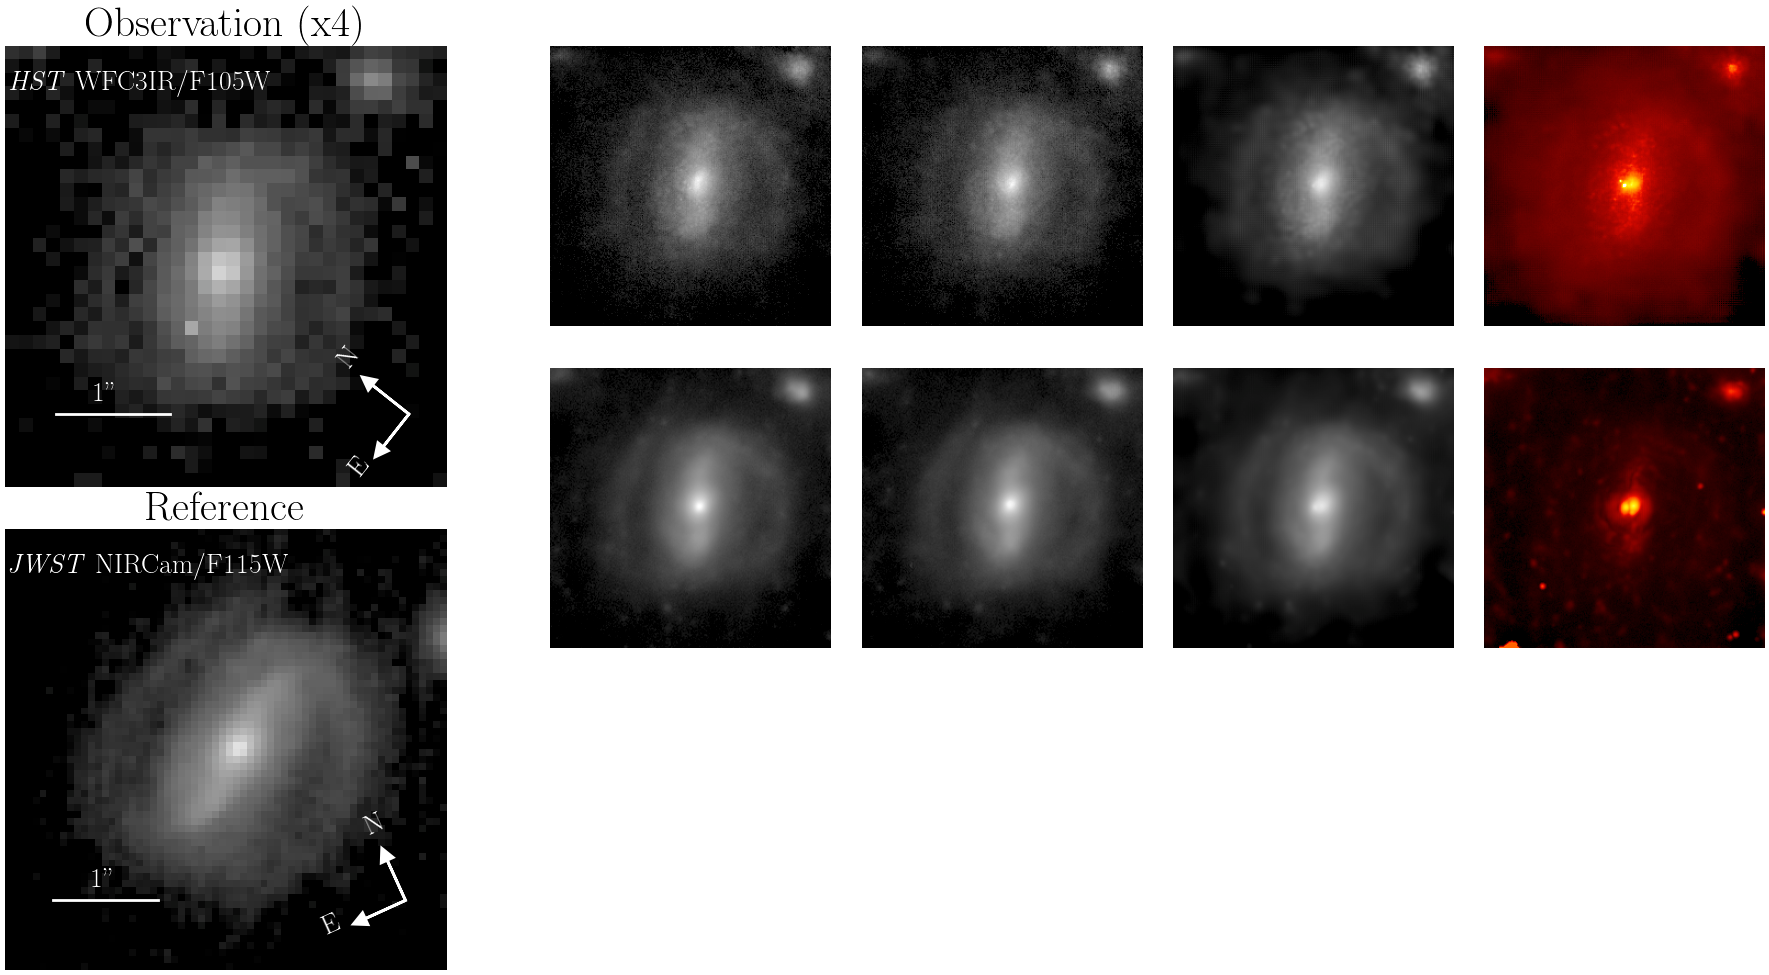

In [441]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

cmap = cc.cm["gray"]
norm = plt.cm.colors.LogNorm(vmin=5e-2, vmax=15, clip=True)
norm_jwst = plt.cm.colors.LogNorm(vmin=1e-2, vmax=5, clip=True)

std_cmap = cc.cm["fire"]
std_norm = plt.cm.colors.LogNorm(vmin=1e-2, vmax=5, clip=True)

# Create a figure
fig = plt.figure(figsize=(24, 12))

# Define the grid
gs = gridspec.GridSpec(6, 5, width_ratios=[3/2, 3/4, 3/4, 3/4, 3/4], height_ratios=[1, 1, 1, 1, 1, 1])

# Create a column with 2 images with space for titles
ax1 = plt.subplot(gs[0:3, 0])
ax1.set_title('Observation (x4)')
ax1.axis('off')  # Turn off axis labels
data_wcs = WCS(data[target][OBS]["SCI"].header, data[target][OBS])
# img = np.rot90(data[target][OBS]["SCI"].data, k=1)
img = np.rot90(observations[target][sde][prior][OBS], k=1)
im1 = ax1.imshow(img, cmap=cmap, norm=norm, origin="lower")
ax1.annotate(r"\textit{HST} WFC3IR/F105W", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
draw_scale_and_compass(ax1, img, data_wcs,  scale=1, x0=0.1, y0=0.15, compass_size=0.1, arrow_size=0.03, color="w", lw=2, textpad=2, fontsize=20)



ax2 = plt.subplot(gs[3:, 0])
ax2.set_title('Reference')
ax2.axis('off')  # Turn off axis labels
im2 = ax2.imshow(jwst_imgs[target], cmap=cmap, norm=norm_jwst, origin="lower") 
ax2.annotate(r"\textit{JWST} NIRCam/F115W", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
draw_scale_and_compass(ax2, jwst_imgs[target], wcs_jwst[target], rotation=90,  scale=1, x0=0.1, y0=0.15, compass_size=0.1, arrow_size=0.03, color="w", lw=2, textpad=4, fontsize=20)

# For each method, show 2 posterior sample, mu and std
for i in range(2):
    ax = plt.subplot(gs[:2, 1+i])
    # axs[0, 2].annotate("VP SDE + SKIRT Prior", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
    k = np.random.randint(imgs[target]["vp"]["skirt"].shape[0])
    ax.imshow(np.rot90(imgs[target]["vp"]["skirt"][k]), cmap=cmap, norm=norm, origin="lower")
    ax.axis("off")
    
    ax = plt.subplot(gs[2:4, 1+i])
    # axs[0, 2].annotate("VP SDE + SKIRT Prior", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
    k = np.random.randint(imgs[target]["vp"]["probes"].shape[0])
    ax.imshow(np.rot90(imgs[target]["vp"]["probes"][k]), cmap=cmap, norm=norm, origin="lower")
    ax.axis("off")

    
ax = plt.subplot(gs[:2, 3])
# axs[0, 2].annotate("VP SDE + SKIRT Prior", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
ax.imshow(np.rot90(imgs[target]["vp"]["skirt"].mean(axis=0)), cmap=cmap, norm=norm, origin="lower")
ax.axis("off")

ax = plt.subplot(gs[2:4, 3])
# axs[0, 2].annotate("VP SDE + SKIRT Prior", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
ax.imshow(np.rot90(imgs[target]["vp"]["probes"].mean(axis=0)), cmap=cmap, norm=norm, origin="lower")
ax.axis("off")


ax = plt.subplot(gs[:2, 4])
# axs[0, 2].annotate("VP SDE + SKIRT Prior", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
ax.imshow(np.rot90(imgs[target]["vp"]["skirt"].std(axis=0)), cmap=std_cmap, norm=std_norm, origin="lower")
ax.axis("off")

ax = plt.subplot(gs[2:4, 4])
# axs[0, 2].annotate("VP SDE + SKIRT Prior", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
ax.imshow(np.rot90(imgs[target]["vp"]["probes"].std(axis=0)), cmap=std_cmap, norm=std_norm, origin="lower")
ax.axis("off")
    

#     ax = plt.subplot(gs[4:, 1+i])
#     # axs[0, 2].annotate("VP SDE + SKIRT Prior", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=20, color="w")
#     k = np.random.randint(imgs[target]["vp"]["probes"].shape[0])
#     ax.imshow(np.rot90(imgs[target]["vp"]["probes"][k]), cmap=cmap, norm=norm, origin="lower")
#     ax.axis("off")
    

# Create a 3x4 grid of images
# for i in range(3):
#     for j in range(1, 5):
#         ax = plt.subplot(gs[i, j])
#         ax.axis('off')  # Turn off axis labels
#         # if j == 1:  # Add row title to the first column of the 3x4 grid
#             # ax.text(-0.5, 0.5, f'Row {i+1}', va='center', ha='center', rotation='vertical', transform=ax.transAxes)

# Adjust the space between the subplots
plt.subplots_adjust(wspace=0.01, hspace=0.35)


# Temporary solution for SMACS

TODO: fixe the orientation, I have to use a fiducial orientation of -24, not 24 to get the right thing, and then rotation by 90 degrees. 

In [226]:
coord1 = SkyCoord("7:23:24.5462", "-73:27:20.172", unit=(units.hourangle, units.deg))
coord2 = SkyCoord("7:23:22.0805", "-73:27:24.575", unit=(units.hourangle, units.deg))
coord3 = SkyCoord("7:23:20.7483", "-73:26:07.203", unit=(units.hourangle, units.deg))

coord = coord2

import sys
sys.path.append("../scripts")
from forward_model import make_wcs

In [159]:
data = np.load("../results/smacs2_temp_solutions_vp_probes_prior.npz")
# data = np.load("../results/smacs2_temp_solutions_vp_skirt_prior.npz")

In [160]:
post_samples = data["sol"]
# observations = data["observations"]
y_hat = data["y_hat"] # reconstructions

In [161]:
target = 2
FILTER = "F105W"
paths = glob.glob(f"../data/smacs*target{target}*{FILTER.upper()}*.fits")
data = []
for p in paths:
    data.append(fits.open(p))

In [162]:
jwst_cutout = fits.open("../data/smacs_jwst_i2d_target2_F115W.fits")
# jwst_cutout = fits.open("../data/smacs_jwst_i2d_target2_F150W.fits")

wcs = WCS(jwst_cutout[1].header)
jwst_img = jwst_cutout[1].data

Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [163]:
# hdr = wcs.to_header()
# hdr["CDELT1"] = 1
# hdr["CDELT2"] = 1
# wcs = WCS(hdr)

In [164]:
# jwst_cutout[1].header

In [224]:
# plt.figure(figsize=(8, 8))
# plt.subplot(projection=wcs)
# plt.imshow(jwst_img, cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-3, vmax=10, clip=True))
# plt.colorbar(fraction=0.047, label=r"MJy / sr", pad=0.01)
# ax = plt.gca()
# draw_scale_and_compass(ax, jwst_img, wcs, rotation=90, scale=1, x0=0.1, y0=0.15, compass_size=0.1, arrow_size=0.01, color="w", lw=2, textpad=5, fontsize=20)
# plt.annotate(r"\textit{JWST} NIRCam F115W", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=25)

# # Set the color of the tick labels
# for tick in ax.get_xticklabels():
#     tick.set_color("white")
# for tick in ax.get_yticklabels():
#     tick.set_color("white")

# # Set the color of the axis labels
# ax.set_ylabel("Declination", color='black')
# ax.set_xlabel("Right ascension", color='black')

# plt.ylabel("Declination")
# plt.xlabel("Right ascension")

# plt.savefig("jwst_f115w_ref_profile.jpg")

In [225]:
# from torch.nn.functional import avg_pool2d
# import torch
# img = avg_pool2d(torch.tensor(np.rot90(post_samples[1, 0], k=-1).copy()).view(1, 1, 256, 256), 4).numpy().squeeze()
# img.shape

# jwst_img.data.shape

# fig, axs = plt.subplots(1, 3, figsize=(12, 4))
# axs[0].plot([32], [32], "r*", markersize=20)
# axs[0].imshow(jwst_img, cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-3, clip=True), origin="lower")
# axs[1].plot([32], [32], "r*", markersize=20)
# axs[1].imshow(img, cmap="magma", norm=plt.cm.colors.LogNorm(), origin="lower")
# im = axs[2].imshow(jwst_img - 0.3*img, cmap="seismic", vmin=-0.4, vmax=0.4, origin="lower")
# plt.colorbar(im, ax=axs[2], fraction=0.047)

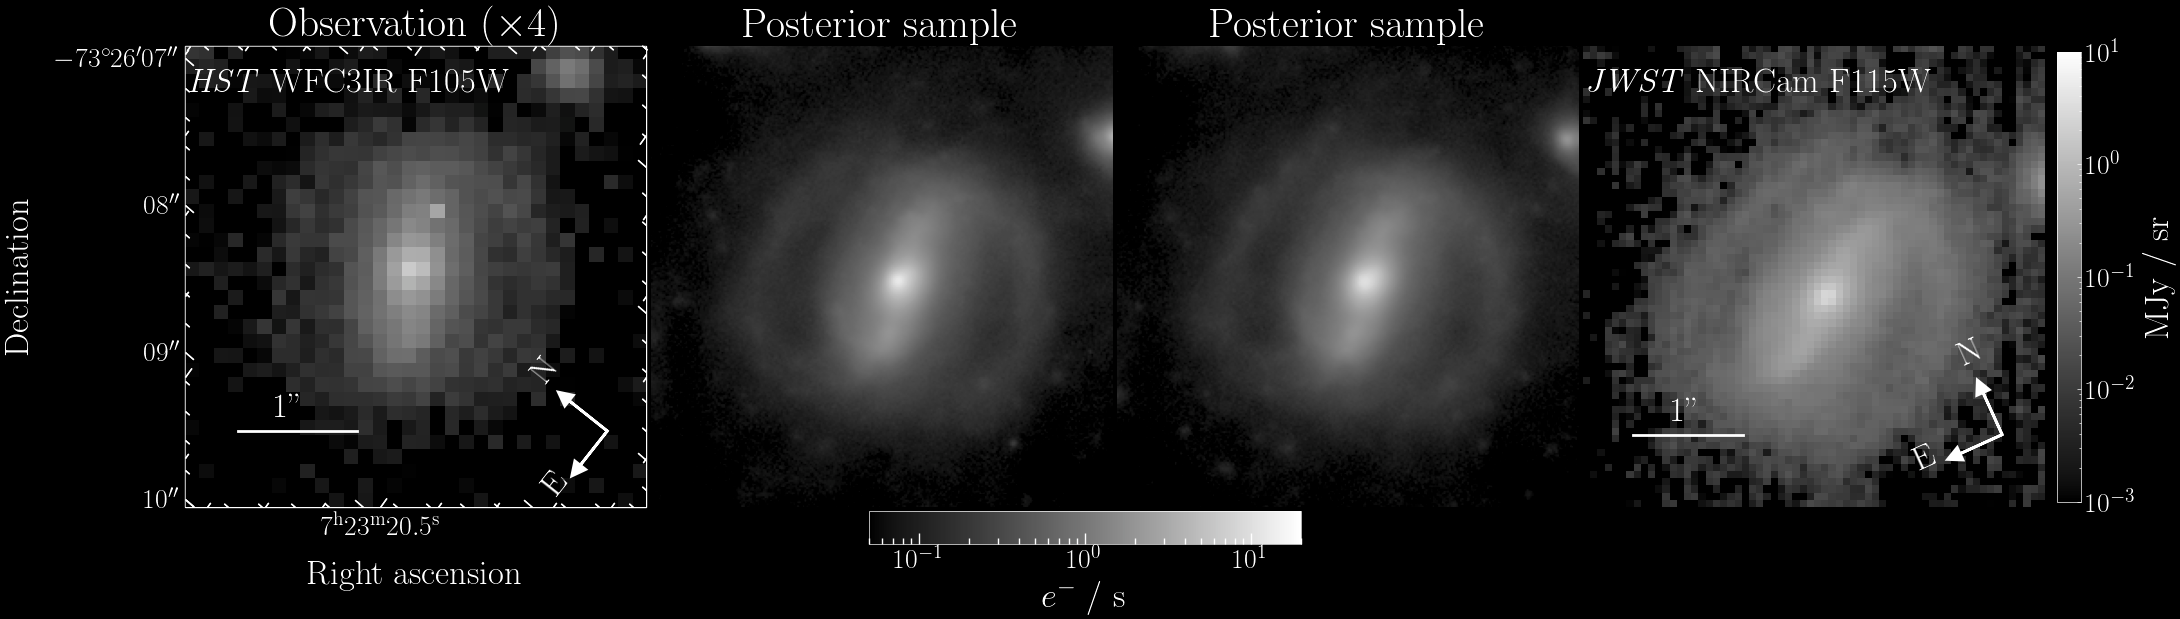

In [117]:
fig = plt.figure(figsize=(24, 6))

jwst_cmap = cc.cm["gray"]
# cmap_std = cc.cm["fire"]
cmap = cc.cm["gray"]
cmap_std = "hot"

norm = plt.cm.colors.LogNorm(vmin=5e-2, vmax=20, clip=True) # change so it makes sense with your units
jwst_norm = plt.cm.colors.LogNorm(vmin=1e-3, vmax=10, clip=True) # change so it makes sense with your units

norm_std = plt.cm.colors.LogNorm(vmin=4e-5, vmax=1e-2, clip=True) # also change this as well

# norm = ImageNormalize(1e3*dirty_image[..., None, None].cpu().numpy(), vmin = 0, stretch = AsinhStretch())

# img = observations[0, 0]#data[2].data

data_wcs = WCS(data[2][1].header, data[2])
img = np.rot90(data[2][1].data, k=1)
ax = fig.add_subplot(141, projection=data_wcs)
im1 = ax.imshow(img, cmap=cmap, norm=norm)
draw_scale_and_compass(ax, img, data_wcs,  scale=1, x0=0.1, y0=0.15, compass_size=0.1, arrow_size=0.03, color="w", lw=2, textpad=2, fontsize=25)
ax.tick_params(axis='both', which='both', color='white')
ax.set_ylabel("Declination")
ax.set_xlabel("Right ascension")
ax.annotate(r"\textit{HST} WFC3IR F105W", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=25)
ax.set_title(r"Observation ($\times 4$)")



img = np.rot90(post_samples[1, 0], k=-1)
ax = fig.add_subplot(int(f"14{2}"))
ax.imshow(img, cmap=cmap, norm=norm, origin="lower")
ax.axis("off")
ax.tick_params(axis='both', which='both', color='white')
ax.set_title("Posterior sample")

img = np.rot90(post_samples[2, 0], k=-1)
ax = fig.add_subplot(int(f"14{3}"))
im = ax.imshow(img, cmap=cmap, norm=norm, origin="lower")
ax.axis("off")
ax.tick_params(axis='both', which='both', color='white')
ax.set_title("Posterior sample")


ax = fig.add_subplot(144, projection=wcs)
im1 = ax.imshow(jwst_img, cmap=jwst_cmap, norm=jwst_norm, origin="lower")
draw_scale_and_compass(ax, jwst_img, wcs, rotation=90, scale=1, x0=0.1, y0=0.15, compass_size=0.1, arrow_size=0.03, color="w", lw=2, textpad=4, fontsize=25)
# ax.tick_params(axis='both', which='both', color='white')
ax.axis("off")
# ax.set_ylabel("Declination")
# ax.set_xlabel("Right ascension")
ax.annotate(r"\textit{JWST} NIRCam F115W", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=25)
# plt.colorbar(im, ax=ax, frac)


cbar_ax = fig.add_axes([0.41, 0.05, 0.18, 0.055])  # Position colorbar at [left, bottom, width, height]
cb1 = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar_ax.set_xlabel(r"$e^{-}$ / s", fontsize=25)

cbar_ax2 = fig.add_axes([0.905, 0.12, 0.01, 0.75])
fig.colorbar(im1, cax=cbar_ax2)
cbar_ax2.set_ylabel(r"MJy / sr", fontsize=25)

plt.subplots_adjust(hspace=0, wspace=0.01)

plt.savefig(f"../results/smacs2_summary_results_temp.png", bbox_inches="tight")

In [103]:
pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(wcs) # in degrees /pixels
pixel_scale_y * jwst_img.shape[0] * 3600

3.9969220368022054

In [100]:
pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(data_wcs) # in degrees /pixels
pixel_scale_y * data[2][1].data.shape[0] * 3600

3.8700813448099716

In [105]:
pixel_scale_x

8.673875947921453e-06